<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/SVM_for_Non_linear_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

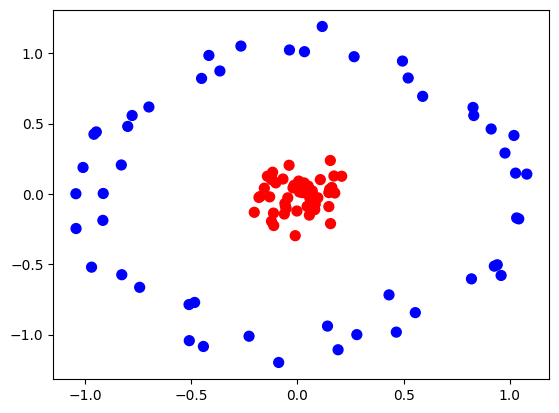

In [6]:
from sklearn.datasets import make_circles
X,y = make_circles(100, factor = .1, noise =.1)

plt.scatter(X[:, 0], X[:,1], c=y, s = 50, cmap ='bwr')

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
#

In [10]:
# First check for Non-linear data

from sklearn.svm import SVC
classifier = SVC(kernel ='linear')
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)


In [9]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

/tmp/ipykernel_17152/477370239.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


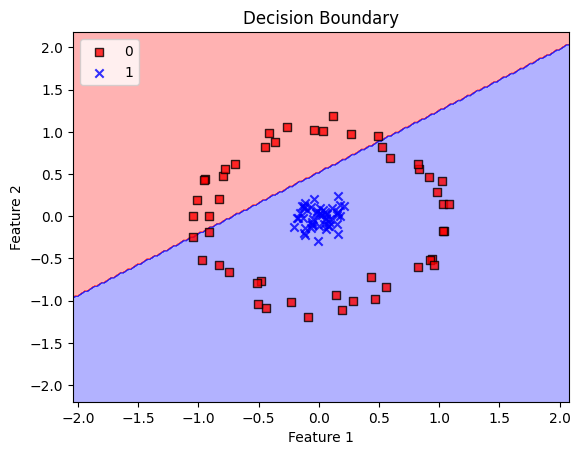

In [13]:
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d

def plot_decision_boundary(X, y, classifier, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=cl,
                    edgecolor='black')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.legend(loc='upper left')
    plt.show()

plot_decision_boundary(X, y, classifier)

In [15]:
# We handle this by using 3D plot instead of 2D

def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax




<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

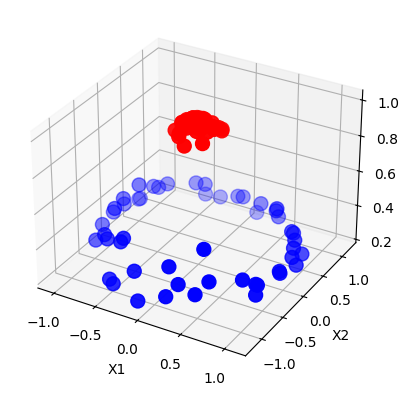

In [16]:
plot_3d_plot(X,y)

In [17]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [20]:
# Accuracy improved now from 0.4 to 1.0

accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_17152/477370239.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


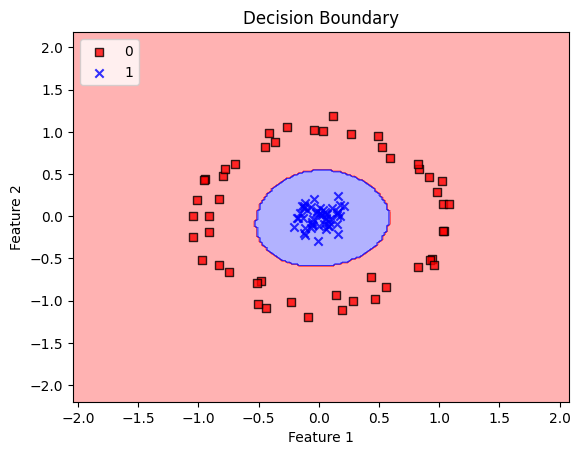

In [19]:
plot_decision_boundary(X, y, rbf_classifier)

In [21]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [22]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_17152/477370239.py:23: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


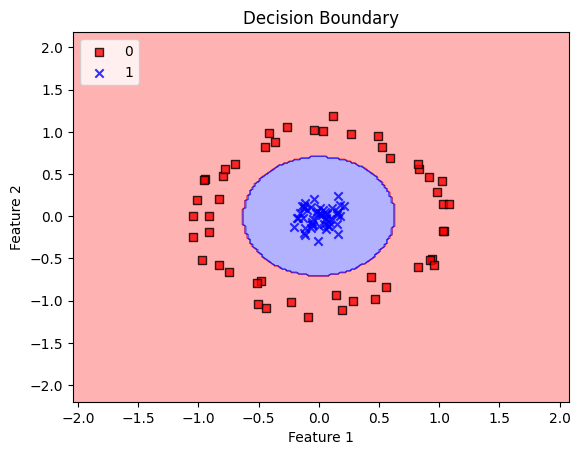

In [23]:
plot_decision_boundary(X, y, poly_classifier)

In [24]:
X_new=np.exp(-(X**2))

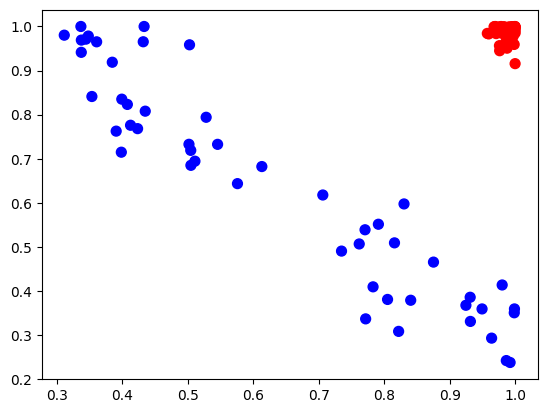

In [25]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')